In [1]:
!mkdir -p ~/work/data_augmentation/data

In [ ]:
!pip install --upgrade pip
!pip install --upgrade torch torchvision

In [3]:
# PyTorch and torchvision
import torch
import torchvision

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt


In [4]:
# GPU 확인
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [5]:
!wget "http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar" -P '/content/'
!tar -xf '/content/images.tar' -C '/content/'

--2026-07-28 06:23:56--  http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar
Resolving vision.stanford.edu (vision.stanford.edu)... 171.64.68.10
Connecting to vision.stanford.edu (vision.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 793579520 (757M) [application/x-tar]
Saving to: ‘/content/images.tar’

images.tar          100%[===================>] 756.82M  36.8MB/s    in 12s     

2026-07-28 06:24:08 (61.9 MB/s) - ‘/content/images.tar’ saved [793579520/793579520]



In [6]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms

dataset_dir = '/content/Images/'

transform = transforms.Compose([
    transforms.Resize((224, 224)),  # 크기 통일
    transforms.ToTensor(),  # Tensor 변환
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # 정규화 추가
])
full_dataset = ImageFolder(root=dataset_dir, transform=transform)

total_size = len(full_dataset)
train_size = int(0.583 * total_size)  # 약 12,000개
test_size = total_size - train_size   # 약 8,580개
ds_train, ds_test = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(ds_train, batch_size=32, shuffle=True)
test_loader = DataLoader(ds_test, batch_size=32, shuffle=False)
ds_info = {
    "num_classes": len(full_dataset.classes),
    "class_names": full_dataset.classes
}



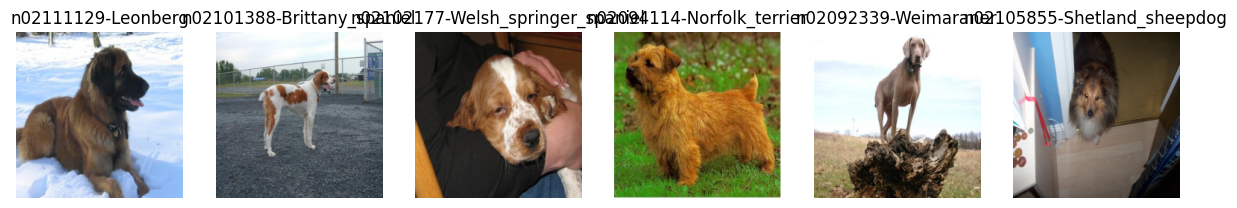

In [7]:
# DataLoader에서 일부 배치 가져오기
def show_examples(data_loader, class_names, num_images=6):
    data_iter = iter(data_loader)
    images, labels = next(data_iter)

    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i in range(num_images):
        image = images[i].permute(1, 2, 0).numpy()  # (C, H, W) → (H, W, C)
        image = (image * 0.5) + 0.5
        image = np.clip(image, 0, 1)

        axes[i].imshow(image)
        axes[i].axis('off')
        axes[i].set_title(class_names[labels[i].item()])

    plt.show()

# 훈련 데이터 샘플 시각화
show_examples(train_loader, ds_info["class_names"])

In [8]:
def normalize_and_resize_img():
    return transforms.Compose([
        transforms.Resize((224, 224)),  # 크기 통일
        transforms.ToTensor(),  # Tensor 변환
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # 정규화 추가
    ])

In [9]:
def normalize_and_resize_img():
    return transforms.Compose([
        transforms.Resize((224, 224)),  # 크기 통일
        transforms.ToTensor(),  # Tensor 변환
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # 정규화 추가
    ])

transform = normalize_and_resize_img()
full_dataset = ImageFolder(root=dataset_dir, transform=transform)

In [10]:
def augment():
    return transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2)
    ])



In [11]:
# 데이터셋을 가공하는 메인함수
def apply_normalize_on_dataset(dataset, is_test=False, batch_size=16, with_aug=False):
    transform = normalize_and_resize_img()

    if not is_test and with_aug:
        dataset.dataset.transform = transforms.Compose([
            *augment().transforms,
            *transform.transforms
        ])
    else:
        dataset.dataset.transform = transform

    return DataLoader(dataset, batch_size=batch_size, shuffle=not is_test, num_workers=2, pin_memory=True)


In [12]:
import random

def augment2():
    return transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),  # 좌우 반전
        transforms.RandomVerticalFlip(p=0.5),    # 상하 반전
        transforms.RandomRotation(degrees=(0, 90, 180, 270)),  # 90도 단위 회전
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),  # 밝기, 대비, 색상 조정
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # 랜덤 크롭 후 리사이즈
        transforms.Lambda(lambda img: torch.clamp(img, 0, 1))  # 0~1 값으로 클리핑
    ])

print('=3')

=3


In [13]:
import torch.nn as nn
import torchvision.models as models

num_classes = len(ds_info["class_names"])
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet50.fc = nn.Linear(resnet50.fc.in_features, num_classes)

print("=3")


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 195MB/s]


=3


In [14]:
aug_resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
aug_resnet50.fc = nn.Linear(aug_resnet50.fc.in_features, num_classes)

print("=3")

=3


In [15]:
ds_train_no_aug = apply_normalize_on_dataset(ds_train, with_aug=False)
ds_train_aug = apply_normalize_on_dataset(ds_train, with_aug=True)
ds_test = apply_normalize_on_dataset(ds_test, is_test=True)

print("=3")

=3


In [ ]:
# [Legacy experiment disabled]
# 최종 실험은 아래 Cell 27~32에서 3개 방법 × 30 Epoch × Seed 42로 실행합니다.
# 기존 3 Epoch 실험은 최종 실험과 중복 실행되므로 비활성화했습니다.


In [17]:
# [Legacy experiment disabled]
# 최종 실험은 아래 Cell 27~32에서 실행합니다.


In [18]:
# [Legacy plot disabled]
# 최종 비교 그래프는 아래 Cell 32에서 생성합니다.


In [19]:
# [Legacy plot disabled]
# 최종 비교 그래프는 아래 Cell 32에서 생성합니다.


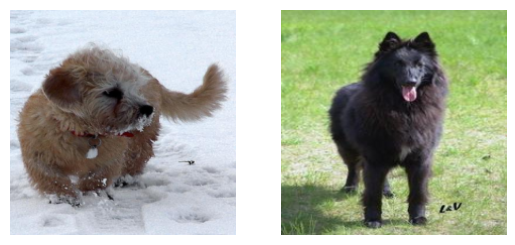

In [20]:
import matplotlib.pyplot as plt

# 데이터셋에서 이미지 2개를 가져옵니다.
data_iter = iter(ds_train_no_aug)
images, labels = next(data_iter)

# 첫 번째 배치에서 두 개의 이미지 선택
image_a = images[0].permute(1, 2, 0).numpy()
image_b = images[1].permute(1, 2, 0).numpy()
label_a = labels[0].item()
label_b = labels[1].item()

# 정규화된 텐서를 다시 [0, 1] 범위로 조정
image_a = (image_a * 0.5) + 0.5
image_b = (image_b * 0.5) + 0.5

# 이미지 출력
plt.subplot(1, 2, 1)
plt.imshow(image_a)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image_b)
plt.axis('off')

plt.show()

In [21]:
def get_clip_box(image_a, image_b):
    # image.shape = (channel, height, width)
    image_size_x = image_a.shape[2]  # Width
    image_size_y = image_a.shape[1]  # Height

    # Get center of box
    x = torch.randint(0, image_size_x, (1,)).item()
    y = torch.randint(0, image_size_y, (1,)).item()

    width = max(1, int(image_size_x * torch.sqrt(1 - torch.rand(1)).item()))
    height = max(1, int(image_size_y * torch.sqrt(1 - torch.rand(1)).item()))

    # Clip box in image and get minmax bbox
    x_min = max(0, x - width // 2)
    y_min = max(0, y - height // 2)
    x_max = min(image_size_x, x + width // 2 + 1)
    y_max = min(image_size_y, y + height // 2 + 1)

    return x_min, y_min, x_max, y_max

x_min, y_min, x_max, y_max = get_clip_box(image_a, image_b)

print('x :', x_min, x_max)
print('y :', y_min, y_max)

x : 1 3
y : 50 224


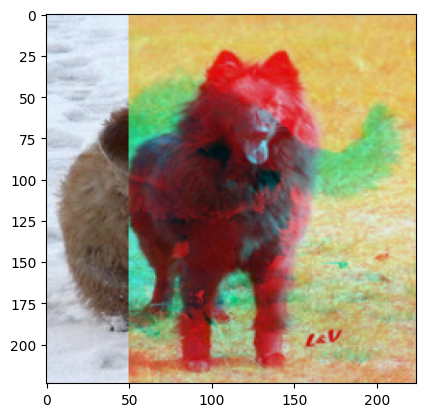

In [22]:
import torch

def mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max):
    # image.shape = (C, H, W)
    image_size_x = image_a.shape[2]  # Width
    image_size_y = image_a.shape[1]  # Height

    if isinstance(image_a, np.ndarray):
        image_a = torch.from_numpy(image_a).to(device)
    if isinstance(image_b, np.ndarray):
        image_b = torch.from_numpy(image_b).to(device)

    top = image_a[:, :y_min, :]
    middle_left = image_a[:, y_min:y_max, :x_min]
    middle_center = image_b[:, y_min:y_max, x_min:x_max]
    middle_right = image_a[:, y_min:y_max, x_max:]
    bottom = image_a[:, y_max:, :]

    top = top.to(device)
    middle_left = middle_left.to(device)
    middle_center = middle_center.to(device)
    middle_right = middle_right.to(device)
    bottom = bottom.to(device)

    # 중간 부분(왼쪽, 중앙, 오른쪽) 결합
    middle = torch.cat([middle_left, middle_center, middle_right], dim=2)

    # 전체 이미지 결합 (위 + 중간 + 아래)
    mixed_img = torch.cat([top, middle, bottom], dim=1)

    return mixed_img

mixed_img = mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max)

plt.imshow(mixed_img.cpu().numpy())
plt.show()

In [23]:
import torch.nn.functional as F

# mix two labels
def mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max, num_classes=120):
    image_size_x = image_a.shape[2]  # Width
    image_size_y = image_a.shape[1]  # Height

    # 바운딩 박스 비율 계산
    mixed_area = (x_max - x_min) * (y_max - y_min)
    total_area = image_size_x * image_size_y
    ratio = mixed_area / total_area

     # 원-핫 벡터 변환
    if isinstance(label_a, int):
        label_a = F.one_hot(torch.tensor(label_a), num_classes=num_classes).float()
    if isinstance(label_b, int):
        label_b = F.one_hot(torch.tensor(label_b), num_classes=num_classes).float()

    # 비율에 따라 라벨 혼합
    mixed_label = (1 - ratio) * label_a + ratio * label_b
    return mixed_label

# 예제 실행
mixed_label = mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max)
print(mixed_label)

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.4821, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.5179, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 

In [ ]:
def cutmix(images, labels, prob=1.0, batch_size=16, img_size=224, num_classes=120):
    mixed_imgs = []
    mixed_labels = []

    for i in range(batch_size):
        image_a = images[i]
        label_a = labels[i]

        j = torch.randint(0, batch_size, (1,)).item()  # 다른 샘플 선택
        image_b = images[j]
        label_b = labels[j]

        # 바운딩 박스 생성
        x_min, y_min, x_max, y_max = get_clip_box(image_a, image_b)

        # 이미지 섞기
        mixed_imgs.append(mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max))
        mixed_labels.append(mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max, num_classes))

    # 텐서 변환
    mixed_imgs = torch.stack(mixed_imgs).reshape(batch_size, 3, img_size, img_size)
    mixed_labels = torch.stack(mixed_labels).reshape(batch_size, num_classes)

    return mixed_imgs, mixed_labels

print("=3")

=3


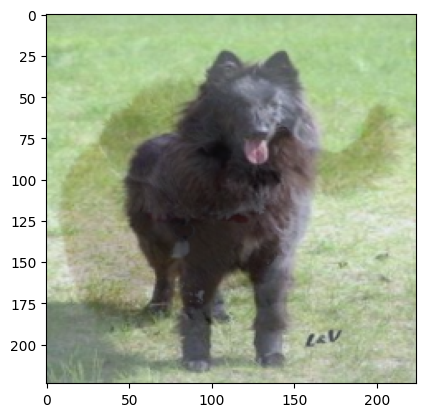

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.3304, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.6696, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 

In [25]:
# function for mixup
def mixup_2_images(image_a, image_b, label_a, label_b, num_classes=120):
    ratio = torch.rand(1).item()  # 0~1 사이의 랜덤 값

    # 라벨 원핫 인코딩
    if isinstance(label_a, int):
        label_a = F.one_hot(torch.tensor(label_a), num_classes=num_classes).float()
    if isinstance(label_b, int):
        label_b = F.one_hot(torch.tensor(label_b), num_classes=num_classes).float()

    # 이미지와 라벨 혼합
    mixed_image = (1 - ratio) * image_a + ratio * image_b
    mixed_label = (1 - ratio) * label_a + ratio * label_b

    return mixed_image, mixed_label

# 예제 실행
mixed_img, mixed_label = mixup_2_images(image_a, image_b, label_a, label_b)

plt.imshow(mixed_img)
plt.show()

print(mixed_label)

In [26]:
def mixup(images, labels, batch_size=16, img_size=224, num_classes=120):
    mixed_imgs = []
    mixed_labels = []

    for i in range(batch_size):
        image_a = images[i]
        label_a = labels[i]

        # 랜덤하게 다른 이미지 선택
        j = torch.randint(0, batch_size, (1,)).item()
        image_b = images[j]
        label_b = labels[j]

        # Mixup 적용
        mixed_img, mixed_label = mixup_2_images(image_a, image_b, label_a, label_b, num_classes)

        mixed_imgs.append(mixed_img)
        mixed_labels.append(mixed_label)

    # 배치 차원 추가
    mixed_imgs = torch.stack(mixed_imgs).view(batch_size, 3, img_size, img_size)  # (B, C, H, W)
    mixed_labels = torch.stack(mixed_labels).view(batch_size, num_classes)  # (B, num_classes)

    return mixed_imgs, mixed_labels



기본 모델및 데이터 설정

In [ ]:
# =========================================================
# Final Experiment Setup
# Stanford Dogs 120 / ResNet50 / 3 Methods x 30 Epoch x 1 Seed
# =========================================================

import os
import copy
import random
import numpy as np
import pandas as pd
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, Subset
from torchvision.models import resnet50, ResNet50_Weights


# -------------------------
# Reproducibility
# -------------------------
SEED = 42


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)


# -------------------------
# Device
# -------------------------
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print('Using device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))


# -------------------------
# Experiment configuration
# -------------------------
DATASET_DIR = '/content/Images/'
BATCH_SIZE = 64
EPOCHS = 30
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4
MIXUP_CUTMIX_ALPHA = 1.0
NUM_WORKERS = 2

METHODS = [
    'no_aug',
    'basic',
    'mixup',
    'cutmix'
]

METHOD_NAMES = {
    'no_aug': 'No Augmentation',
    'basic': 'Basic Augmentation',
    'mixup': 'Basic + Mixup',
    'cutmix': 'Basic + CutMix'
}


# -------------------------
# ImageNet normalization
# -------------------------
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


# Validation에는 Random Augmentation을 절대 적용하지 않음
val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])


# No Augmentation: 크기 조정 + Normalize만 수행
train_transform_no_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])


# Basic Augmentation
train_transform_basic = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])


# -------------------------
# Fixed split
# 모든 실험이 정확히 동일한 Train/Validation index를 사용
# -------------------------
base_dataset = torchvision.datasets.ImageFolder(
    root=DATASET_DIR
)

num_classes = len(base_dataset.classes)
num_samples = len(base_dataset)

indices = np.arange(num_samples)
rng = np.random.default_rng(SEED)
rng.shuffle(indices)

train_size = int(0.8 * num_samples)
train_indices = indices[:train_size].tolist()
val_indices = indices[train_size:].tolist()

print('Number of classes:', num_classes)
print('Total images:', num_samples)
print('Train images:', len(train_indices))
print('Validation images:', len(val_indices))


# -------------------------
# Dataset / DataLoader factory
# -------------------------
def build_loaders(train_transform, batch_size=BATCH_SIZE):
    train_dataset_full = torchvision.datasets.ImageFolder(
        root=DATASET_DIR,
        transform=train_transform
    )

    val_dataset_full = torchvision.datasets.ImageFolder(
        root=DATASET_DIR,
        transform=val_transform
    )

    train_dataset = Subset(
        train_dataset_full,
        train_indices
    )

    val_dataset = Subset(
        val_dataset_full,
        val_indices
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    return train_loader, val_loader


# No Augmentation과 Basic Augmentation은 각각 별도의 Transform 사용
train_loader_no_aug, val_loader = build_loaders(
    train_transform_no_aug
)

train_loader_basic, _ = build_loaders(
    train_transform_basic
)

print('No Augmentation batches:', len(train_loader_no_aug))
print('Basic Augmentation batches:', len(train_loader_basic))


Using device: cuda
GPU: Tesla T4
Number of classes: 120
Total images: 20580
Train images: 16464
Validation images: 4116
No Augmentation batches: 258
Basic Augmentation batches: 258


MixUp & CutMix 구현

In [33]:
# =========================================================
# Mixup & CutMix
# =========================================================

def soft_target_cross_entropy(logits, targets):
    """Soft label을 사용하는 Mixup/CutMix용 Cross Entropy."""
    log_probs = F.log_softmax(logits, dim=1)
    return -(targets * log_probs).sum(dim=1).mean()


def mixup_batch(images, labels, alpha=1.0, num_classes=120):
    """Batch 단위 Mixup. randperm은 image와 동일한 device에서 생성."""
    lam = np.random.beta(alpha, alpha)
    batch_size = images.size(0)

    rand_index = torch.randperm(
        batch_size,
        device=images.device
    )

    mixed_images = (
        lam * images
        + (1.0 - lam) * images[rand_index]
    )

    label_a = F.one_hot(
        labels,
        num_classes=num_classes
    ).float()

    label_b = F.one_hot(
        labels[rand_index],
        num_classes=num_classes
    ).float()

    mixed_labels = (
        lam * label_a
        + (1.0 - lam) * label_b
    )

    return mixed_images, mixed_labels


def rand_bbox(size, lam):
    """Tensor shape [N, C, H, W] 기준 CutMix bounding box."""
    H = size[2]
    W = size[3]

    cut_rat = np.sqrt(1.0 - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    cx = np.random.randint(W)
    cy = np.random.randint(H)

    x1 = np.clip(cx - cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y2 = np.clip(cy + cut_h // 2, 0, H)

    return x1, y1, x2, y2


def cutmix_batch(images, labels, alpha=1.0, num_classes=120):
    """Batch 단위 CutMix. 실제 교체 면적으로 lambda를 재계산."""
    lam = np.random.beta(alpha, alpha)
    batch_size = images.size(0)

    rand_index = torch.randperm(
        batch_size,
        device=images.device
    )

    x1, y1, x2, y2 = rand_bbox(
        images.size(),
        lam
    )

    mixed_images = images.clone()

    # Tensor shape [N, C, H, W] -> [y1:y2, x1:x2]
    mixed_images[:, :, y1:y2, x1:x2] = (
        images[rand_index, :, y1:y2, x1:x2]
    )

    # 실제 교체된 면적 기준 lambda 재계산
    area = (x2 - x1) * (y2 - y1)
    total_area = images.size(-1) * images.size(-2)

    lam = 1.0 - (area / total_area)

    label_a = F.one_hot(
        labels,
        num_classes=num_classes
    ).float()

    label_b = F.one_hot(
        labels[rand_index],
        num_classes=num_classes
    ).float()

    mixed_labels = (
        lam * label_a
        + (1.0 - lam) * label_b
    )

    return mixed_images, mixed_labels


모델 학습 루틴


In [ ]:
# =========================================================
# Model Training Routine
# =========================================================

def create_model(num_classes, initial_state=None):
    """동일한 ImageNet pretrained 초기 가중치에서 각 실험을 시작."""
    model = resnet50(
        weights=ResNet50_Weights.DEFAULT
    )

    model.fc = nn.Linear(
        model.fc.in_features,
        num_classes
    )

    if initial_state is not None:
        model.load_state_dict(initial_state)

    return model.to(device)


# 동일한 초기 pretrained model을 모든 실험에서 공유
set_seed(SEED)
_initial_model = create_model(num_classes)
INITIAL_STATE = copy.deepcopy(
    _initial_model.state_dict()
)
del _initial_model


def train_model(
    train_loader,
    val_loader,
    num_classes,
    aug_method='no_aug',
    epochs=30,
    lr=0.001,
    weight_decay=1e-4,
    alpha=1.0,
    initial_state=None
):
    # 실험마다 동일한 seed 및 초기 가중치 사용
    set_seed(SEED)

    model = create_model(
        num_classes,
        initial_state=initial_state
    )

    optimizer = optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=0.9,
        weight_decay=weight_decay
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    history = {
        'train_loss': [],
        'val_loss': [],
        'val_accuracy': []
    }

    best_val_acc = 0.0
    best_epoch = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        total = 0

        for images, labels in train_loader:
            images = images.to(
                device,
                non_blocking=True
            )
            labels = labels.to(
                device,
                non_blocking=True
            )

            # Basic loader를 사용하면 이미 Basic Augmentation이 적용됨
            if aug_method == 'mixup':
                images, targets = mixup_batch(
                    images,
                    labels,
                    alpha=alpha,
                    num_classes=num_classes
                )
            elif aug_method == 'cutmix':
                images, targets = cutmix_batch(
                    images,
                    labels,
                    alpha=alpha,
                    num_classes=num_classes
                )
            else:
                targets = labels

            optimizer.zero_grad(set_to_none=True)

            outputs = model(images)

            if aug_method in ['mixup', 'cutmix']:
                loss = soft_target_cross_entropy(
                    outputs,
                    targets
                )
            else:
                loss = F.cross_entropy(
                    outputs,
                    targets
                )

            loss.backward()
            optimizer.step()

            running_loss += (
                loss.item() * images.size(0)
            )
            total += images.size(0)

        scheduler.step()

        train_loss = running_loss / total

        # Validation: Mixup/CutMix를 적용하지 않음
        model.eval()
        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(
                    device,
                    non_blocking=True
                )
                labels = labels.to(
                    device,
                    non_blocking=True
                )

                outputs = model(images)

                loss = F.cross_entropy(
                    outputs,
                    labels
                )

                val_loss_sum += (
                    loss.item() * images.size(0)
                )

                predicted = outputs.argmax(dim=1)

                val_total += labels.size(0)
                val_correct += (
                    predicted == labels
                ).sum().item()

        val_loss = val_loss_sum / val_total
        val_acc = 100.0 * val_correct / val_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            best_model_state = copy.deepcopy(
                model.state_dict()
            )

        print(
            f'[{epoch + 1:02d}/{epochs}] '
            f'Train Loss: {train_loss:.4f} | '
            f'Val Loss: {val_loss:.4f} | '
            f'Val Acc: {val_acc:.2f}%'
        )

    if best_model_state is not None:
        model.load_state_dict(
            best_model_state
        )

    return {
        'model': model,
        'history': history,
        'best_val_acc': best_val_acc,
        'best_epoch': best_epoch
    }


In [ ]:
# =========================================================
# FINAL EXPERIMENT
# 3 Methods x 30 Epoch x 1 Seed
# =========================================================

results = {}

# No Augmentation
print('\n' + '=' * 70)
print('1/4 - No Augmentation')
print('=' * 70)
results['no_aug'] = train_model(
    train_loader_no_aug,
    val_loader,
    num_classes,
    aug_method='no_aug',
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    initial_state=INITIAL_STATE
)

# Basic Augmentation
print('\n' + '=' * 70)
print('2/4 - Basic Augmentation')
print('=' * 70)
results['basic'] = train_model(
    train_loader_basic,
    val_loader,
    num_classes,
    aug_method='basic',
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    initial_state=INITIAL_STATE
)

# Basic Augmentation + Mixup
print('\n' + '=' * 70)
print('3/4 - Basic + Mixup')
print('=' * 70)
results['mixup'] = train_model(
    train_loader_basic,
    val_loader,
    num_classes,
    aug_method='mixup',
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    alpha=MIXUP_CUTMIX_ALPHA,
    initial_state=INITIAL_STATE
)

# Basic Augmentation + CutMix
print('\n' + '=' * 70)
print('4/4 - Basic + CutMix')
print('=' * 70)
results['cutmix'] = train_model(
    train_loader_basic,
    val_loader,
    num_classes,
    aug_method='cutmix',
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    alpha=MIXUP_CUTMIX_ALPHA,
    initial_state=INITIAL_STATE
)


# =========================================================
# 결과 요약
# =========================================================
rows = []

for method in METHODS:
    result = results[method]
    history = result['history']

    rows.append({
        'Method': METHOD_NAMES[method],
        'Best Val Accuracy (%)': result['best_val_acc'],
        'Best Epoch': result['best_epoch'],
        'Final Val Accuracy (%)': history['val_accuracy'][-1],
        'Final Val Loss': history['val_loss'][-1]
    })

results_df = pd.DataFrame(rows).sort_values(
    by='Best Val Accuracy (%)',
    ascending=False
).reset_index(drop=True)

print('\n' + '=' * 70)
print('FINAL RESULTS')
print('=' * 70)
print(results_df.to_string(index=False))


# =========================================================
# Validation Accuracy 비교
# =========================================================
plt.figure(figsize=(10, 6))

for method in METHODS:
    history = results[method]['history']
    plt.plot(
        range(1, EPOCHS + 1),
        history['val_accuracy'],
        label=METHOD_NAMES[method]
    )

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.title('Validation Accuracy Comparison - ResNet50')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =========================================================
# Validation Loss 비교
# =========================================================
plt.figure(figsize=(10, 6))

for method in METHODS:
    history = results[method]['history']
    plt.plot(
        range(1, EPOCHS + 1),
        history['val_loss'],
        label=METHOD_NAMES[method]
    )

plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss Comparison - ResNet50')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =========================================================
# Best Validation Accuracy Bar Chart
# =========================================================
plt.figure(figsize=(10, 6))

labels = [METHOD_NAMES[m] for m in METHODS]
accuracies = [
    results[m]['best_val_acc']
    for m in METHODS
]

bars = plt.bar(
    labels,
    accuracies
)

for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{acc:.2f}%',
        ha='center',
        va='bottom'
    )

plt.ylabel('Best Validation Accuracy (%)')
plt.title('Best Validation Accuracy Comparison')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# =========================================================
# CSV 저장
# =========================================================
results_df.to_csv(
    'augmentation_results_4methods_30epochs_seed42.csv',
    index=False
)

print(
    'Saved: augmentation_results_4methods_30epochs_seed42.csv'
)


# =========================================================
# Best Model 저장
# =========================================================
os.makedirs('checkpoints', exist_ok=True)

for method in METHODS:
    result = results[method]

    save_path = os.path.join(
        'checkpoints',
        f'resnet50_{method}_best_seed42.pth'
    )

    torch.save(
        {
            'model_state_dict': result['model'].state_dict(),
            'best_val_acc': result['best_val_acc'],
            'best_epoch': result['best_epoch'],
            'method': method,
            'seed': SEED,
            'epochs': EPOCHS,
            'num_classes': num_classes
        },
        save_path
    )

    print('Saved:', save_path)


print('\n' + '=' * 70)
print('EXPERIMENT COMPLETED')
print('=' * 70)



1/4 - No Augmentation
[01/30] Train Loss: 4.2391 | Val Loss: 3.0915 | Val Acc: 68.85%
[02/30] Train Loss: 1.8107 | Val Loss: 0.8683 | Val Acc: 84.77%
[03/30] Train Loss: 0.7418 | Val Loss: 0.5343 | Val Acc: 87.59%
[04/30] Train Loss: 0.5091 | Val Loss: 0.4415 | Val Acc: 88.58%
[05/30] Train Loss: 0.3968 | Val Loss: 0.3951 | Val Acc: 89.02%
[06/30] Train Loss: 0.3215 | Val Loss: 0.3710 | Val Acc: 89.19%
[07/30] Train Loss: 0.2725 | Val Loss: 0.3575 | Val Acc: 89.19%
[08/30] Train Loss: 0.2323 | Val Loss: 0.3500 | Val Acc: 89.14%
[09/30] Train Loss: 0.1984 | Val Loss: 0.3419 | Val Acc: 89.50%
[10/30] Train Loss: 0.1701 | Val Loss: 0.3398 | Val Acc: 89.29%
[11/30] Train Loss: 0.1498 | Val Loss: 0.3363 | Val Acc: 89.43%
[12/30] Train Loss: 0.1350 | Val Loss: 0.3427 | Val Acc: 89.21%
[13/30] Train Loss: 0.1215 | Val Loss: 0.3383 | Val Acc: 89.33%
[14/30] Train Loss: 0.1106 | Val Loss: 0.3402 | Val Acc: 89.50%
[15/30] Train Loss: 0.0986 | Val Loss: 0.3428 | Val Acc: 89.04%
[16/30] Train Los

본 실험에서는 Stanford Dogs 120 데이터셋과 ImageNet 사전학습 ResNet50을
사용하여 No Augmentation, Mixup, CutMix의 세 가지 조건을 비교하였다.

No Augmentation을 기준선으로 설정하여 증강 기법 적용에 따른
일반화 성능 변화를 확인하였으며, 동일한 조건에서
Mixup과 CutMix의 상대적인 성능을 비교하였다.

실험 결과, CutMix가 가장 높은 Best Validation Accuracy를
기록하였다. 따라서 본 실험 조건에서는 [CutMix]가
Stanford Dogs 120 분류 문제에서 가장 우수한 일반화 성능을 보였다고
판단할 수 있다.

다만 본 실험에서는 Basic Augmentation 단독 조건을 별도로 측정하지
않았으므로, Mixup과 CutMix의 성능 향상을 각각의 기법 자체의 순수한
효과로 단정할 수는 없다. 정확한 증강 효과를 분리하여 분석하려면
No Augmentation → Basic Augmentation → Basic + Mixup/CutMix의
추가 실험이 필요하다.

## 최종 실험 결과 해석 

이번 노트북의 최종 실험은 다음 3가지 조건을 동일한 데이터 분할과 동일한 초기 가중치에서 비교합니다.

1. **No Augmentation**: Resize + Normalize
2. **Mixup**: Mixup
3. **CutMix**: CutMix

모든 방법은 **Stanford Dogs 120 / ImageNet Pretrained ResNet50 / 30 Epoch / Seed 42** 조건으로 학습합니다.

최종 성능은 `Best Validation Accuracy`를 기준으로 비교합니다. Mixup과 CutMix는 Soft Label을 사용하므로 기존의 hard-label Train Accuracy와 직접 비교하지 않고, 동일한 Validation Set에서 측정한 Validation Accuracy와 Validation Loss를 중심으로 해석합니다.

> 주의: 3개 방법의 성능 차이는 데이터셋, 초기 가중치, 학습률, Epoch 등에 따라 달라질 수 있으므로 특정 증강 기법이 항상 우수하다고 단정하지 않습니다. 본 실험의 결과를 기준으로 결론을 작성합니다.
